<a href="https://colab.research.google.com/github/angiemarian123456-art/METODOS-NUMERICOS-1/blob/main/metodo_de_biseccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iter a           b           p           f(p)        Error       
-----------------------------------------------------------------
1    1.0000000   2.0000000   1.5000000   2.3750000   0.5000000
2    1.0000000   1.5000000   1.2500000   -1.7968750   0.2500000
3    1.2500000   1.5000000   1.3750000   0.1621094   0.1250000
4    1.2500000   1.3750000   1.3125000   -0.8483887   0.0625000
5    1.3125000   1.3750000   1.3437500   -0.3509827   0.0312500
6    1.3437500   1.3750000   1.3593750   -0.0964088   0.0156250
7    1.3593750   1.3750000   1.3671875   0.0323558   0.0078125
8    1.3593750   1.3671875   1.3632812   -0.0321500   0.0039062
9    1.3632812   1.3671875   1.3652344   0.0000720   0.0019531
10   1.3632812   1.3652344   1.3642578   -0.0160467   0.0009766
11   1.3642578   1.3652344   1.3647461   -0.0079893   0.0004883
12   1.3647461   1.3652344   1.3649902   -0.0039591   0.0002441
13   1.3649902   1.3652344   1.3651123   -0.0019437   0.0001221
14   1.3651123   1.3652344   1.3651733  

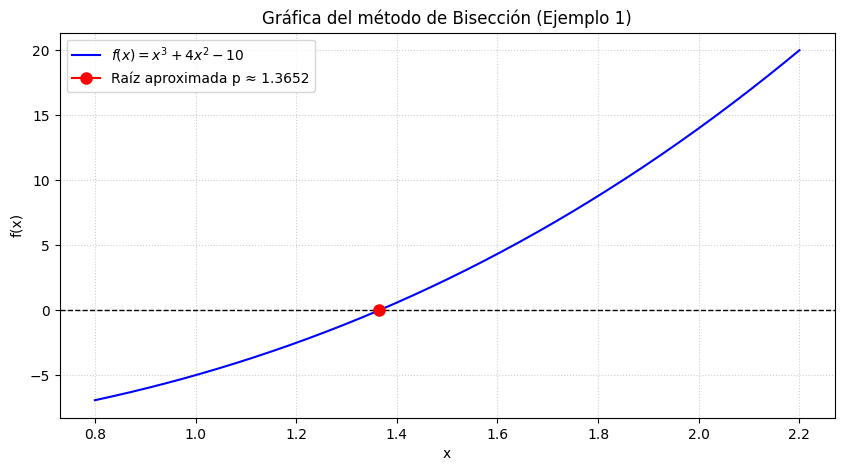

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#### 1. IMPLEMENTACIÓN DEL ALGORITMO 2.1 BURDEN ####
def metodo_biseccion(f, a, b, tol, max_iter):
    # Validamos que el intervalo inicial sirva según el Teorema del Valor Intermedio
    if f(a) * f(b) >= 0:
        print("Error: La función no cambia de signo en el intervalo dado.")
        return None, []

    i = 1
    FA = f(a)
    historial =[]

    # Ciclo principal del algoritmo de bisección
    while i <= max_iter:
        p = a + (b - a) / 2
        FP = f(p)
        error = (b - a) / 2

        # Guardamos los datos para la tabla de resultados
        historial.append([i, a, b, p, FP, error])

        # Raíz exacta
        if FP == 0 or error < tol:
            return p, historial

        i += 1

        # Extremos del intervalo
        if FA * FP > 0:
            a = p
            FA = FP
        else:
            b = p

    print("El método terminó por alcanzar el máximo de iteraciones.")
    return p, historial

#### 2. DEFINICIÓN DEL EJEMPLO 1 PÁG. 38 ####
# Definimos la función f(x) = x^3 + 4x^2 - 10
def f(x):
    return x**3 + 4*x**2 - 10

# Parámetros del problema
a_inicial = 1.0
b_inicial = 2.0
tolerancia = 1e-4
max_iteraciones = 50

# Ejecutamos el método de bisección
raiz, tabla = metodo_biseccion(f, a_inicial, b_inicial, tolerancia, max_iteraciones)

# Imprimimos la tabla con los resultados tabulados de forma limpia
print(f"{'Iter':<5}{'a':<12}{'b':<12}{'p':<12}{'f(p)':<12}{'Error':<12}")
print("-" * 65)
for fila in tabla:
    print(f"{fila[0]:<5}{fila[1]:.7f}   {fila[2]:.7f}   {fila[3]:.7f}   {fila[4]:.7f}   {fila[5]:.7f}")

print("\n" + "="*45)
print(f"Raíz aproximada encontrada: p = {raiz:.7f}")
print(f"Total de iteraciones realizadas: {len(tabla)}")
print("="*45 + "\n")

#### GRAFICA ####
# Generamos puntos en el eje X para dibujar la curva
x_puntos = np.linspace(0.8, 2.2, 200)
y_puntos = f(x_puntos)

plt.figure(figsize=(10, 5))
plt.plot(x_puntos, y_puntos, label='$f(x) = x^3 + 4x^2 - 10$', color='blue', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línea del eje X

# Si se encontró la raíz, la marcamos con un punto rojo
if raiz:
    plt.plot(raiz, 0, marker='o', color='red', markersize=8, label=f'Raíz aproximada p ≈ {raiz:.4f}')

plt.title('Gráfica del método de Bisección (Ejemplo 1)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()
